# Two-Point Correlation Function

Real-space `xi(r)` for GALFORM central galaxies using Corrfunc. For production runs over many subvolumes, use the subvol-weighted estimator (see `subvol_weighted_example.ipynb`).

In [5]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np

import galform_analysis
from galform_analysis import set_base_dir, get_base_dir, SimulationConfig, load_redshift_mapping

mpl.setconfig()

# Configure the path to your GALFORM output directory once per session:
# set_base_dir('/cosma5/data/durham/<user>/Galform_Out/L800/model')
BASE_DIR = str(get_base_dir())
SIM = 'L800'

## Single subvolume

In [6]:
from galform_analysis.analysis.correlation import (
    correlation_given_redshift_and_subvolume,
    avg_correlation_given_redshift_and_subvolumes,
    avg_correlation_given_subvolume_and_redshifts,
)
from galform_analysis.config import get_snapshot_redshift
import os

iz_path = os.path.join(BASE_DIR, 'iz155')
xi_single = correlation_given_redshift_and_subvolume(iz_path, ivol=0)
print(f"r range: {xi_single['r'].min():.2f} – {xi_single['r'].max():.2f} Mpc/h")

r range: 0.12 – 27.96 Mpc/h


## Average over multiple subvolumes

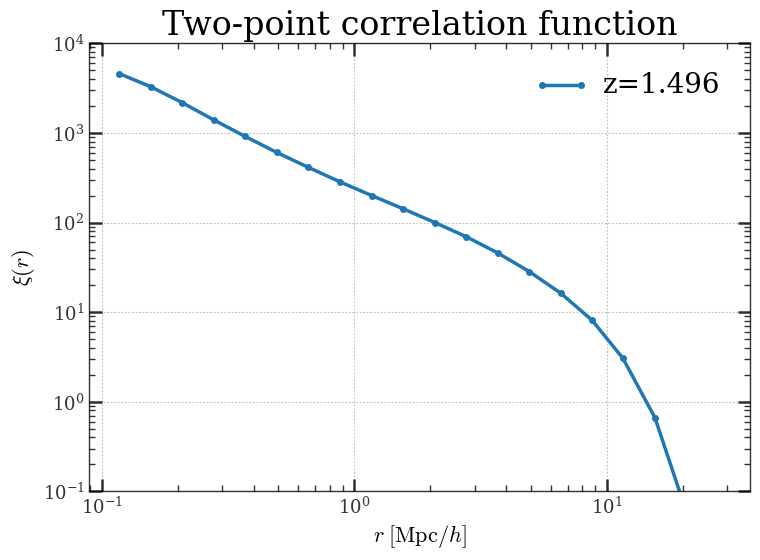

In [9]:
IZ_NUM = 155
IVOLS  = list(range(4))

z = get_snapshot_redshift(f'iz{IZ_NUM}', SIM)
xi = avg_correlation_given_redshift_and_subvolumes(IZ_NUM, IVOLS, base_dir=BASE_DIR)

fig, ax = plt.subplots()
ax.plot(xi['r'], xi['xi'], 'o-', ms=4, label=f'z={z:.3f}')
ax.axhline(0, color='0.5', lw=0.8, ls='--')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel(r'$r\;[\mathrm{Mpc}/h]$')
ax.set_ylabel(r'$\xi(r)$')
ax.set_title('Two-point correlation function')
ax.set_ylim(1e-1, 1e4)
ax.legend()
fig.tight_layout()
plt.show()

## Redshift evolution (one subvolume)

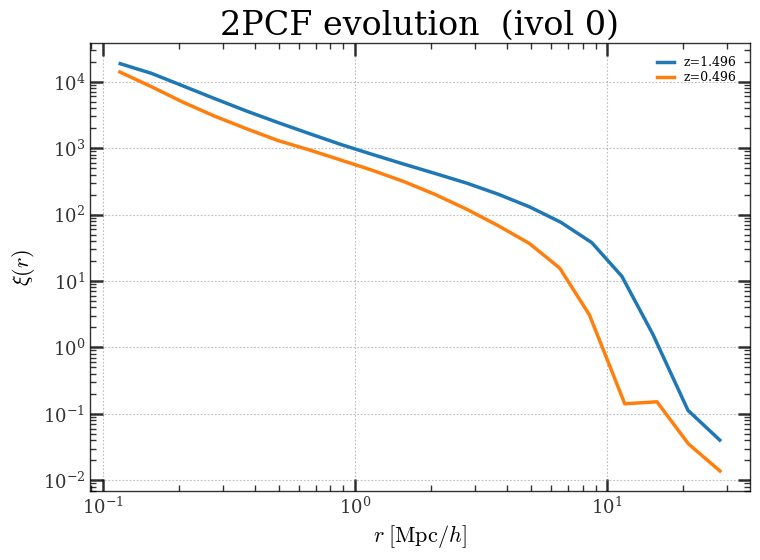

In [10]:
IZ_NUMS = [82, 120, 155, 207]
IVOL    = 0

fig, ax = plt.subplots()
for iz_num in IZ_NUMS:
    iz_p = os.path.join(BASE_DIR, f'iz{iz_num}')
    xi_z = correlation_given_redshift_and_subvolume(iz_p, ivol=IVOL)
    if xi_z is None:
        continue
    z = get_snapshot_redshift(f'iz{iz_num}', SIM)
    ax.plot(xi_z['r'], xi_z['xi'], label=f'z={z:.3f}')
ax.axhline(0, color='0.5', lw=0.8, ls='--')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel(r'$r\;[\mathrm{Mpc}/h]$')
ax.set_ylabel(r'$\xi(r)$')
ax.set_title('2PCF evolution  (ivol 0)')
ax.legend(fontsize=9)
fig.tight_layout()
plt.show()